# 02 — Time Perspective

This notebook analyses the time perspective of the student-journey case study. We compare the journeys of students who **graduate on time** and those who **graduate late**. Both come ready from `00_preprocess.ipynb`.

The comparison slices the journeys along their **semesters**: every semester is a window, and
the **compass method** is fitted over all of them at once. One compass on the **unfiltered
log** — every recorded student, no cohorts — fixes the shared output space; a frozen-output
model is then retrained for every `(log, semester)`, for each cohort and for the unfiltered log
itself. All of them are scored against that one compass, so they share one coordinate system.
Two readings follow from it:

- **drift**, a log against its **own past**: the change between adjacent semesters, one line per
  cohort, with the unfiltered log's own line as the reference — the programme as a whole,
  independent of the cohort split;
- **cross-cohort similarity**, the two cohorts against **each other** inside one semester:
  which shared courses they treat differently at that point in the journey.

The notebook runs in four steps:

1. **Train** — load the logs, fit the compass on the unfiltered log, then one frozen-output
   model per `(log, semester)`, cohorts and reference alike; each model is cached under
   `results/artefacts`.
2. **Summary** — the two drift lines against the combined reference, the cross-cohort
   similarity per semester, and the same numbers as a table and a CSV.
3. **Drill-down A** — at a chosen semester, which courses drove *one cohort's* change.
4. **Drill-down B** — in a chosen semester, which courses the *two cohorts* differ on.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import log_comparison_block as lcb  # the shared block-structured architecture

SEED = 42
lcb.set_seed(SEED)

# --- folders, anchored on this notebook's own directory
BASE_DIR = Path(lcb.__file__).resolve().parent
LOG_DIR = BASE_DIR / "data" / "preprocessed"
RESULTS_DIR = BASE_DIR / "results"  # the result tables
ARTEFACTS_DIR = RESULTS_DIR / "artefacts"  # the trained models
ARTEFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- the two cohorts, and the unfiltered log the compass is fitted on
NAMES = ("on-time", "late")
COMBINED = "all students"
LOG_PATHS = {n: LOG_DIR / f"students_{n}.csv" for n in NAMES}
LOG_PATHS[COMBINED] = LOG_DIR / "students_full.csv"  # unfiltered: the whole recording
PERIOD_COLUMN = "time:timestamp"  # one semester per value, e.g. `2018/1`

# --- architecture and training schedule
C = 2  # context window c, in blocks (= semesters)
EMBEDDING_DIM = 32
UNIT_NORM = True  # keep the embeddings on the unit sphere: every embedding is
# L2-normalised before it enters the context vector, and the read-out is normalised too,
# so a course (or value) is described by its direction alone -- what the cosine reads
LEARNING_RATE_COMPASS, EPOCHS_COMPASS = 1e-2, 1000
LEARNING_RATE, EPOCHS = 1e-2, 1000
DEVICE = "cpu"  # many small full-batch runs are faster on the CPU than on MPS


# --- where the results go: one file per window model, plus the summary table
def model_path(name, window):
    return ARTEFACTS_DIR / f"02_time_{name}_{window.replace('/', '-')}.pt"


COMPASS_PATH = ARTEFACTS_DIR / "02_time_compass.pt"
SUMMARY_PATH = RESULTS_DIR / "02_time_drift-similarity.csv"

# True retrains every window, False reuses the cached models
RECOMPUTE_EMBEDDINGS = False

for n, p in LOG_PATHS.items():
    assert p.exists(), f"log {n!r} not found: {p} — run 00_preprocess.ipynb first"

## 2. Train the models (compass method)

Both cohorts come ready from `00_preprocess.ipynb`, one block per semester: the events a
student has in a semester form that block, and the semester is its period. `students_full.csv`
holds the same journeys unfiltered — every recorded student, unfinished ones included — so it
still describes the last semesters, where the cohorts hold nothing but graduations. It is both
the log the compass is fitted on and, as a log of its own, the reference line.

A window is one `(log, semester)`, and a training sample belongs to the window of its **target**
block: predicting a semester from the `c` preceding ones is what that window is fitted on. The
first `c` semesters have no full context and the last is too thin to fit, so no window is
modelled for them — their events still serve as *context* for the neighbouring windows.

One **compass** model, fitted on the unfiltered log, fixes the shared output matrix
$\mathbf{E}_{\mathrm{out}}$; every `(log, semester)` window is then retrained from it with that
output **frozen**, so only its input embeddings move — against one and the same output space.
The cohorts never enter the compass, only the retraining, where each is fitted on its own
samples alone.

That is what keeps the balancing simple. The compass sees no cohorts, only semesters, so the
windows are the one thing left to weigh against each other: `balance_compass=True` scales every
semester up to the busiest one, since otherwise the high-enrolment semesters fix the output
space alone and the quiet ones are read against a space they had no part in. The **late** cohort
being some four times the size of the **on-time** one never has to be corrected for, because the
two are never in the compass together. Every window is still retrained on its own, unscaled
samples.

The models are cached individually. If `RECOMPUTE_EMBEDDINGS = False`, they are loaded instead
of retrained.

In [11]:
logs = {n: pd.read_csv(p) for n, p in LOG_PATHS.items()}

# the semesters of the recording, and the windows a model is fitted for: the first
# C lack a full context, the last is a handful of graduations
PERIODS = {n: sorted(df[PERIOD_COLUMN].unique()) for n, df in logs.items()}
all_periods = sorted({p for ps in PERIODS.values() for p in ps})
EXCLUDE_WINDOWS = all_periods[:C] + all_periods[-1:]
WINDOWS = {n: [p for p in ps if p not in EXCLUDE_WINDOWS] for n, ps in PERIODS.items()}

In [12]:
if RECOMPUTE_EMBEDDINGS:
    # one compass on the unfiltered log, then a model per (log, semester) from it —
    # the cohorts and the reference alike, so all three lines live in one space
    models, compass = lcb.compare_block_event_logs_over_time(
        logs,
        logs[COMBINED],
        c=C,
        embedding_dim=EMBEDDING_DIM,
        compass_learning_rate=LEARNING_RATE_COMPASS,
        compass_epochs=EPOCHS_COMPASS,
        window_learning_rate=LEARNING_RATE,
        window_epochs=EPOCHS,
        exclude_windows=EXCLUDE_WINDOWS,
        unit_norm=UNIT_NORM,
        balance_compass=True,
        device=DEVICE,
        # the compass stage reports the factors it rescales the windows by; the
        # window stage is quiet — set it True for a bar and a loss curve per window
        compass_verbose=True,
        window_verbose=True,
        time_col=PERIOD_COLUMN,
    )
    for (name, window), model in models.items():
        lcb.save_model(model, model_path(name, window))
    lcb.save_model(compass, COMPASS_PATH)
else:
    models = {
        (n, w): lcb.load_model(model_path(n, w), device=DEVICE)
        for n in LOG_PATHS
        for w in WINDOWS[n]
        if model_path(n, w).exists()
    }

## 3. Summary

**Drift** is a cohort against its own past: between two adjacent semesters and over the courses
both windows are fitted on, the halved cosine distance $\tfrac{1}{2}(1 - sim)$ of each course's
two embeddings, averaged. It runs from `0` (the semester changed nothing) to `1` (every course
turned around), so a **peak marks a semester where that cohort's course-behaviour changed**.

The **reference line** is the same score on the unfiltered log's own windows: the programme as
a whole, cohort split or not. It comes from the same compass as the cohort lines, so the three
are directly comparable rather than three separate spaces.

**Cross-cohort similarity** is the two cohorts against each other *inside* one semester: the
mean cosine over the courses both are fitted on there, so **low = the cohorts differ at that
point**. It answers a different question from drift — the other cohort, not the own past — and
gets a chart of its own over the same semester axis.

A drift score belongs to the interval between two windows and is drawn at the midpoint between
their ticks; the similarity is measured *in* one window and sits on its tick — which is why the
first window carries a similarity but no drift. The table below carries both, colour-coded over
their full range, red (`0` similarity / `1` drift, the two differ) through yellow to green (`1`
similarity / `0` drift, the two behave alike).

The same numbers go to `02_time_drift-similarity.csv`.

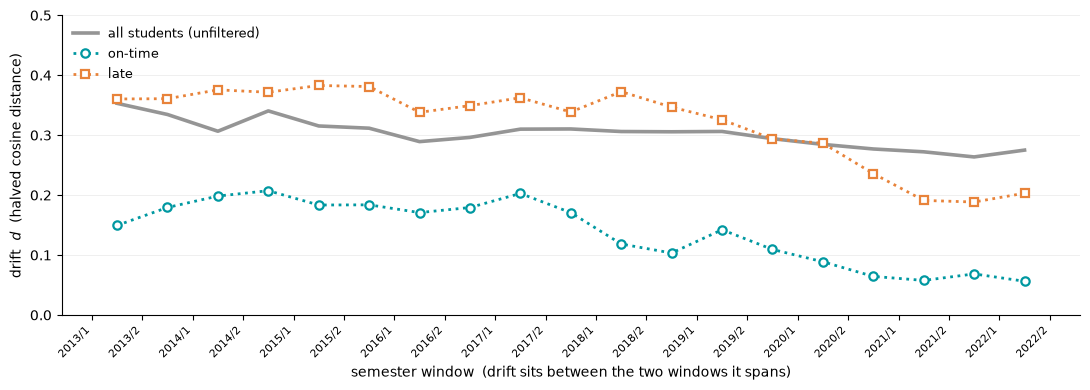

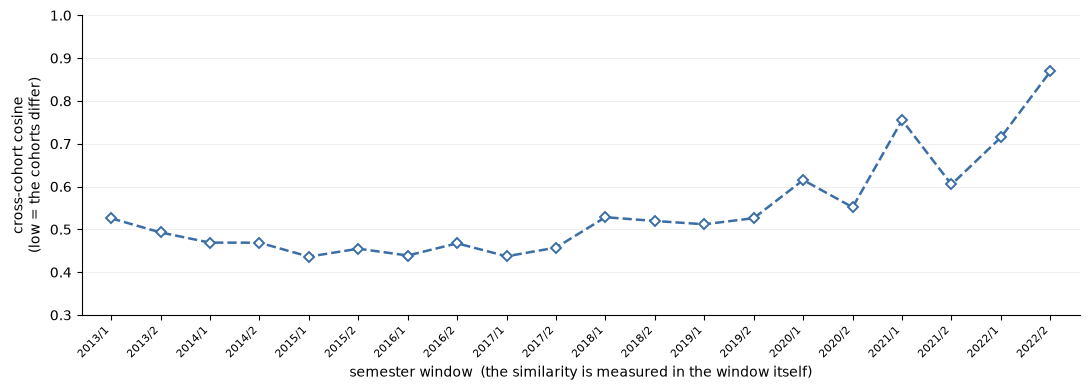

In [13]:
COHORT_COLOR = {"on-time": "#0098A1", "late": "#E8833A"}
COMBINED_COLOR = "#8a8a8a"  # gray — every recorded student, the reference
SIMILARITY_COLOR = "#3B6EA5"  # blue — a cross-cohort quantity, as in the drill-down
COHORT_MARKER = {"on-time": "o", "late": "s"}  # a second cue besides the colour

drift, drift_per_course = lcb.drift_scores(models)  # the cohorts AND the reference
similarity, similarity_per_course = lcb.cross_log_scores(models, *NAMES)

# one tick per semester window; a drift score spans two of them, so it is drawn at
# their midpoint, while a similarity is measured in one window and sits on its tick
sems = sorted({w for ws in WINDOWS.values() for w in ws})
at = {s: i for i, s in enumerate(sems)}
x_window = np.arange(len(sems))


def between(index):
    """The x of a drift score: the midpoint between the two windows it spans."""
    return np.array([at[s] - 0.5 for s in index])


fig_drift, ax = plt.subplots(figsize=(11, 4.0))
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.35)
ax.plot(
    between(drift.index),
    drift[COMBINED].to_numpy(dtype=float),
    color=COMBINED_COLOR,
    linewidth=2.6,
    alpha=0.9,
    label=f"{COMBINED} (unfiltered)",
    zorder=2,
)
for n in NAMES:
    ax.plot(
        between(drift.index),
        drift[n].to_numpy(dtype=float),
        color=COHORT_COLOR[n],
        linewidth=2,
        linestyle=":",
        marker=COHORT_MARKER[n],
        markersize=6,
        markerfacecolor="white",
        markeredgecolor=COHORT_COLOR[n],
        markeredgewidth=1.6,
        label=n,
        zorder=3,
    )
ax.set_ylim(0.0, 0.5)
ax.set_ylabel("drift  $d$  (halved cosine distance)")
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig_similarity, ax2 = plt.subplots(figsize=(11, 4.0))
ax2.set_axisbelow(True)
ax2.yaxis.grid(True, linewidth=0.4, alpha=0.35)
ax2.plot(
    x_window,
    similarity.reindex(sems).to_numpy(dtype=float),
    color=SIMILARITY_COLOR,
    linewidth=1.8,
    linestyle="--",
    marker="D",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=SIMILARITY_COLOR,
    markeredgewidth=1.4,
    label="cross-cohort sim",
    zorder=3,
)
ax2.set_ylim(0.3, 1.0)
ax2.set_ylabel("cross-cohort cosine\n(low = the cohorts differ)")
ax2.tick_params(axis="y")

# the same semester axis under both charts, but each score sits differently on it
ax.set_xlabel("semester window  (drift sits between the two windows it spans)")
ax2.set_xlabel("semester window  (the similarity is measured in the window itself)")
for a in (ax, ax2):
    a.set_xticks(x_window)
    a.set_xticklabels(sems, rotation=45, ha="right", fontsize=8)
    a.set_xlim(-0.6, len(sems) - 0.4)
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
    a.figure.tight_layout()
plt.show()

### One figure for the paper

The same numbers as above, on a **single similarity axis**. Drift is the halved cosine distance,
$d = \tfrac{1}{2}(1 - sim)$, so it reads back as a similarity through $sim = 1 - 2d$ — and the
averaging is linear, so this recovers the mean cosine exactly rather than approximating it.

That puts all four lines in one unit, on one axis: three **cross-window** similarities, each log
against its own previous semester, and the **cross-cohort** similarity, the two cohorts against
each other inside a semester. High is alike in both cases.

Saved to `results/02_time_chart.pdf`.


chart -> /Users/felixgross/Documents/Python Projects/Embedding Comparison/02. case-study/results/02_time_chart.pdf


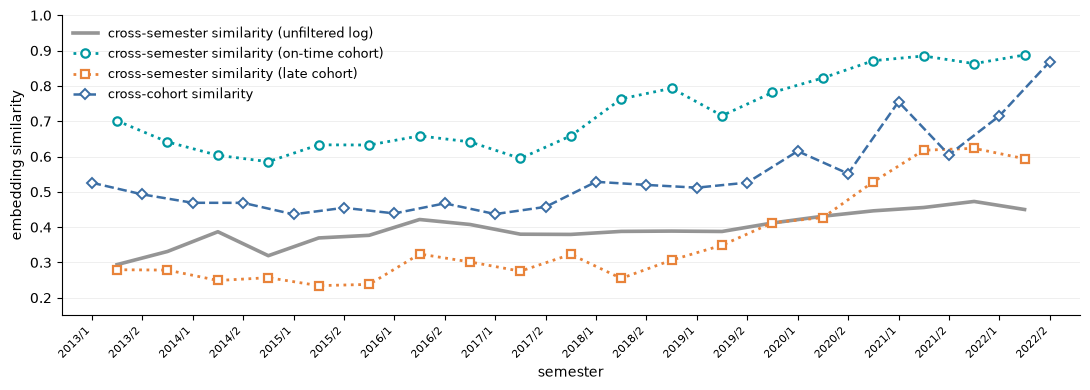

In [19]:
PAPER_PATH = RESULTS_DIR / "02_time_chart.pdf"

# d = (1 - sim)/2  ->  sim = 1 - 2d. The mean is linear, so this is the mean cosine
# itself, not an approximation of it.
cross_window = 1.0 - 2.0 * drift.astype(float)
cross_cohort = similarity.reindex(sems).astype(float)

fig_paper, axp = plt.subplots(figsize=(11, 4.0))
axp.set_axisbelow(True)
axp.yaxis.grid(True, linewidth=0.4, alpha=0.35)

# a cross-window score spans two semesters and is drawn between their ticks; a
# cross-cohort score is measured inside one and sits on its tick
axp.plot(
    between(cross_window.index),
    cross_window[COMBINED].to_numpy(dtype=float),
    color=COMBINED_COLOR,
    linewidth=2.6,
    alpha=0.9,
    label="cross-semester similarity (unfiltered log)",
    zorder=2,
)
for n in NAMES:
    axp.plot(
        between(cross_window.index),
        cross_window[n].to_numpy(dtype=float),
        color=COHORT_COLOR[n],
        linewidth=2,
        linestyle=":",
        marker=COHORT_MARKER[n],
        markersize=6,
        markerfacecolor="white",
        markeredgecolor=COHORT_COLOR[n],
        markeredgewidth=1.6,
        label=f"cross-semester similarity ({n} cohort)",
        zorder=3,
    )
axp.plot(
    x_window,
    cross_cohort.to_numpy(dtype=float),
    color=SIMILARITY_COLOR,
    linewidth=1.8,
    linestyle="--",
    marker="D",
    markersize=5,
    markerfacecolor="white",
    markeredgecolor=SIMILARITY_COLOR,
    markeredgewidth=1.4,
    label="cross-cohort similarity",
    zorder=4,
)

axp.set_xlabel("semester")
axp.set_ylabel("embedding similarity")
axp.set_xticks(x_window)
axp.set_xticklabels(sems, rotation=45, ha="right", fontsize=8)
axp.set_xlim(-0.6, len(sems) - 0.4)
lowest = float(
    np.nanmin([np.nanmin(cross_window.to_numpy(dtype=float)), np.nanmin(cross_cohort)])
)
axp.set_ylim(max(0.0, np.floor(lowest * 20) / 20 - 0.05), 1.0)
axp.legend(frameon=False, fontsize=9, loc="upper left")
for side in ("top", "right"):
    axp.spines[side].set_visible(False)
fig_paper.tight_layout()
fig_paper.savefig(PAPER_PATH, bbox_inches="tight")
print(f"chart -> {PAPER_PATH}")
plt.show()


## 4. Drill-down A — what changed *within* one cohort

Pick a cohort and a semester, and read the **per-course decomposition of one point on that
cohort's drift line**: how far each course it shares with the previous semester moved between
the two, the terms the average above is taken over.

Both ends of the ranking are drawn, per cohort: the `TOP_K` courses that drifted **most** (upper
row, solid) and the `TOP_K` that drifted **least** (lower row, lighter) — the ones whose
behavioural context sat still across the pair.

The last column decomposes the **overall** drift the same way: the unfiltered log's own point at
that semester — the grey reference line of the summary chart — so a course that moves for the
programme as a whole can be told apart from one that moves for a single cohort.

In [15]:
DRILL_WINDOW = "2015/1"  # the LATER semester of the pair, a modelled window
TOP_K = 5

PANELS = ("most drifted", "least drifted")

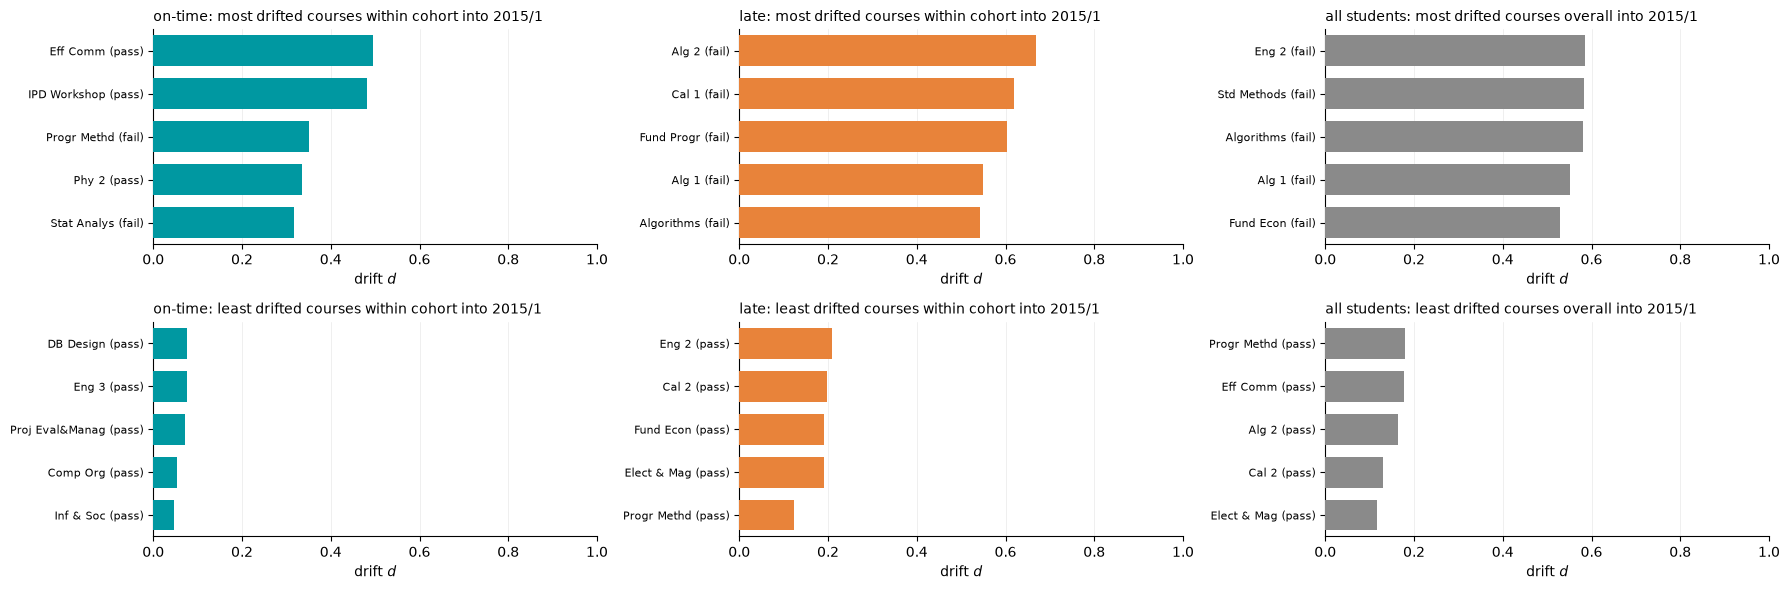

In [16]:
DRILL_LOGS = (*NAMES, COMBINED)  # the two cohorts, then the unfiltered reference
DRILL_COLOR = {**COHORT_COLOR, COMBINED: COMBINED_COLOR}
DRILL_SCOPE = {**dict.fromkeys(NAMES, "within cohort"), COMBINED: "overall"}

fig, axes = plt.subplots(
    len(PANELS),
    len(DRILL_LOGS),
    figsize=(6.0 * len(DRILL_LOGS), max(3.0, 0.32 * TOP_K) * len(PANELS)),
    squeeze=False,
)
for j, n in enumerate(DRILL_LOGS):
    course = drift_per_course[n][DRILL_WINDOW].dropna().sort_values(ascending=False)
    selection = {
        PANELS[0]: course.head(TOP_K),
        PANELS[1]: course.tail(TOP_K),  # the least moved first
    }
    for i, panel in enumerate(PANELS):
        top = selection[panel]
        ax = axes[i][j]
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linewidth=0.4, alpha=0.35)
        ax.barh(
            np.arange(len(top)),
            top.to_numpy(dtype=float),
            height=0.72,
            color=DRILL_COLOR[n],
            zorder=3,
        )
        ax.set_yticks(np.arange(len(top)))
        ax.set_yticklabels(top.index, fontsize=8)
        ax.set_ylim(len(top) - 0.5, -0.5)  # the panel's leading course at the top
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel(r"drift $d$")
        ax.tick_params(axis="x")
        ax.set_title(
            f"{n}: {panel} courses {DRILL_SCOPE[n]} into {DRILL_WINDOW}",
            loc="left",
            fontsize=10,
        )
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()


## 5. Drill-down B — what the *two cohorts* differ on in one semester

Pick a semester, and read the **per-course decomposition of one point on the similarity line**:
for every course both cohorts are fitted on there, the cosine between their two embeddings —
**low = the cohorts treat the course differently**. Nothing here looks at an adjacent semester;
it is a snapshot of one point in the journey, not a change between two.

Both ends of the ranking are drawn: the `TOP_K` courses the cohorts **agree on least** (upper,
solid) and the `TOP_K` they **agree on most** (lower, lighter).

In [17]:
DRILL_SEMESTER = "2015/1"  # a window both cohorts are modelled over

PANELS_B = ("most shifted", "most stable")

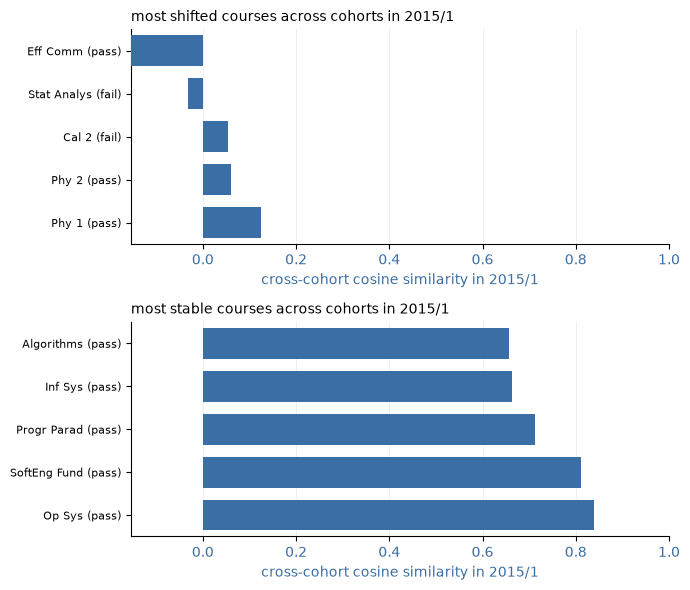

In [18]:
course = similarity_per_course[DRILL_SEMESTER].dropna().sort_values()
selection = {
    PANELS_B[0]: course.head(TOP_K),
    PANELS_B[1]: course.tail(TOP_K),
}

fig, axes = plt.subplots(
    len(PANELS_B),
    1,
    figsize=(7.0, max(3.0, 0.32 * TOP_K) * len(PANELS_B)),
    squeeze=False,
)
for ax, panel in zip(axes.flat, PANELS_B, strict=True):
    top = selection[panel]
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linewidth=0.4, alpha=0.35)
    ax.barh(
        np.arange(len(top)),
        top.to_numpy(dtype=float),
        height=0.72,
        color=SIMILARITY_COLOR,
        zorder=3,
    )
    ax.set_yticks(np.arange(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.set_ylim(len(top) - 0.5, -0.5)  # the panel's leading course at the top
    ax.set_xlim(min(0.0, float(course.min())), 1.0)
    ax.set_xlabel(
        f"cross-cohort cosine similarity in {DRILL_SEMESTER}",
        color=SIMILARITY_COLOR,
    )
    ax.tick_params(axis="x", labelcolor=SIMILARITY_COLOR)
    ax.set_title(
        f"{panel} courses across cohorts in {DRILL_SEMESTER}", loc="left", fontsize=10
    )
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()